In [1]:
import csv
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import copy

In [2]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [6]:
def min_max_vals(x_list, y_list):
    x = np.array(x_list, dtype=np.float32).reshape(-1, 1)
    y = np.array(y_list, dtype=np.float32).reshape(-1, 1)
    return x.min(), x.max(), y.min(), y.max()

In [3]:

class MLP:
    def __init__(self, layer_num, act_func, w, biases_w, x_min=None, x_max=None, y_min=None, y_max=None):
        self.layer_num = layer_num
        self.w = w
        self.biases_w = biases_w
        self.act_func = act_func

        self.x_min = x_min 
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max

    def layer_calc(self, layer_id, x):
        if layer_id < len(self.layer_num) - 2:
            return self.act_func(x @ self.w[layer_id] + self.biases_w[layer_id])
        else:
            return x @ self.w[layer_id] + self.biases_w[layer_id]

    def calc(self, x):
        temp = x.copy()
        if (self.x_min is not None) and (self.x_max is not None):
            temp = (temp - self.x_min) / (self.x_max - self.x_min)
        for layer_id in range(len(self.layer_num) - 1):
            temp = self.layer_calc(layer_id, temp)
        if (self.y_min is not None) and (self.y_max is not None):
            temp = temp * (self.y_max - self.y_min) + self.y_min
            
        return temp

In [4]:

data_square_simple = csv.reader(open('mio1/regression/square-simple-training.csv'))
test_data_square_simple = csv.reader(open('mio1/regression/square-simple-test.csv'))
data_steps_large = csv.reader(open('mio1/regression/steps-large-training.csv'))
test_data_steps_large = csv.reader(open('mio1/regression/steps-large-test.csv'))

### Proces trenowania, najlepszy model square simple poniżej

Skrypt pozwoli na stworzenie modelu i wytrenowanie go. Po zakończonym trenowaniu należy wyciągnąć wartości weight i bias z warstw liniowych i przekopiować je do swojego modelu napisanego w Numpy (przekopiować wartości).
Proszę o zapisanie wykresów trenowania i pokazanie ich na następnych zajęciach (może być w formie surowej po prostu screenów).

In [53]:
# Stwórz odpowiedni model w miejsce kropek: model z jedną warstwą ukrytą z 5 neuronami, model z jedną warstwa ukrytą z 10 neuronami, model z dwiema warstwami ukrytymi z 5 neuronami.
# Do stworzenia modelu wykorzystaj: nn.Sequential, nn.Linear, nn.Sigmoid
# nn.Linear - https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
# nn.Sequential - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
# nn.Sigmoid - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html

# Trenujemy i testujemy po jednym modelu na raz. Testowanie następnego modelu wymaga włączenie wszystkich komórek jeszcze raz.

model_1_5_1_nietr = nn.Sequential(
    nn.Linear(1, 5),
    nn.Sigmoid(),
    nn.Linear(5, 1)
)

model_1_10_1_nietr = nn.Sequential(
    nn.Linear(1, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1)
)

model_1_5_5_1_nietr = nn.Sequential(
    nn.Linear(1, 5),
    nn.Sigmoid(),
    nn.Linear(5, 5),
    nn.Sigmoid(),
    nn.Linear(5, 1)
)


In [55]:
# Jeżeli jest dostępne GPU to wykonaj trening na GPU, jeśli nie to na CPU

device = torch.device("cpu")
model_1_5_1_nietr.to(device)
model_1_10_1_nietr.to(device)
model_1_5_5_1_nietr.to(device)

print(f"Trening zostanie wykonany na {device}")

Trening zostanie wykonany na cpu


In [7]:
# najpierw square simple

In [5]:
# square simple
x_list_square_simple = []
y_list_square_simple = []
for i, row in enumerate(data_square_simple):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    x_list_square_simple.append(x)
    y_list_square_simple.append(y)

# Przygotuj dane testujace
test_x_list_square_simple = []
test_y_list_square_simple = []
for i, row in enumerate(test_data_square_simple):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    test_x_list_square_simple.append(x)
    test_y_list_square_simple.append(y)


In [9]:

czy_znormalizowac = True
model_1_5_1 = copy.deepcopy(model_1_5_1_nietr)
model_1_10_1 = copy.deepcopy(model_1_10_1_nietr)
model_1_5_5_1 = copy.deepcopy(model_1_5_5_1_nietr)

In [10]:
# Trening
def trening(model, x_list, y_list, dlugosc_treningu):
    model = model.to(device)
    model.train()

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    x = torch.tensor(x_list, dtype=torch.float32).reshape(-1, 1).to(device)
    y = torch.tensor(y_list, dtype=torch.float32).reshape(-1, 1).to(device)

    if czy_znormalizowac:
        x_min, x_max = x.min(), x.max()
        y_min, y_max = y.min(), y.max()

        x_norm = (x - x_min) / (x_max - x_min)
        y_norm = (y - y_min) / (y_max - y_min)
    else:
        x_norm = x
        y_norm = y
        x_min = x_max = y_min = y_max = None

    lista_modeli = []
    lista_strat = []
    lista_krokow = []

    for i in range(dlugosc_treningu):

        y_pred = model(x_norm)
        loss = criterion(y_pred, y_norm)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0 and i != 0:
            print(f"Krok {i}, strata: {loss.item()}")

            model_copy = copy.deepcopy(model)
            model_copy.eval()
            lista_modeli.append(model_copy)
            lista_strat.append(loss.item())
            lista_krokow.append(i)

    model.eval()
    with torch.no_grad():
        y_pred = model(x_norm)

        if czy_znormalizowac:
            y_pred_denorm = y_pred * (y_max - y_min) + y_min
            final_loss = criterion(y_pred_denorm, y)
            print(f"Końcowa strata (nieznormalizowana): {final_loss.item()}")
        else:
            final_loss = criterion(y_pred, y)
            print(f"Końcowa strata: {final_loss.item()}")

    x_plot = x.cpu().numpy()
    y_plot = y.cpu().numpy()

    if czy_znormalizowac:
        y_pred_plot = y_pred_denorm.cpu().numpy()
    else:
        y_pred_plot = y_pred.cpu().numpy()

    plt.scatter(x_plot, y_plot)
    plt.scatter(x_plot, y_pred_plot)
    plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
    plt.title("Przewidziane i prawdziwe wartości")
    plt.show()

    plt.figure()
    plt.plot(lista_krokow, lista_strat)
    plt.xlabel("Krok")
    plt.ylabel("Strata")
    plt.title("Strata co 100 kroków")
    plt.show()

    return model, lista_modeli, x_min.item(), x_max.item(), y_min.item(), y_max.item()

Krok 100, strata: 0.062073804438114166
Krok 200, strata: 0.04974742978811264
Krok 300, strata: 0.005002284422516823
Krok 400, strata: 0.00026073839399032295
Krok 500, strata: 0.00018055127293337137
Krok 600, strata: 0.00013295041571836919
Krok 700, strata: 9.851263166638091e-05
Krok 800, strata: 7.260489655891433e-05
Krok 900, strata: 5.330375279299915e-05
Krok 1000, strata: 3.921525421901606e-05
Krok 1100, strata: 2.908699752879329e-05
Krok 1200, strata: 2.183244032494258e-05
Krok 1300, strata: 1.6710300769773312e-05
Krok 1400, strata: 1.2935892300447449e-05
Krok 1500, strata: 1.0238017239316832e-05
Krok 1600, strata: 8.22528909338871e-06
Krok 1700, strata: 6.751989076292375e-06
Krok 1800, strata: 5.628882263408741e-06
Krok 1900, strata: 4.904552497464465e-06
Krok 2000, strata: 4.142036686971551e-06
Krok 2100, strata: 3.557214586180635e-05
Krok 2200, strata: 3.2697491860744776e-06
Krok 2300, strata: 2.96985899694846e-06
Krok 2400, strata: 2.775765096885152e-06
Krok 2500, strata: 2.557

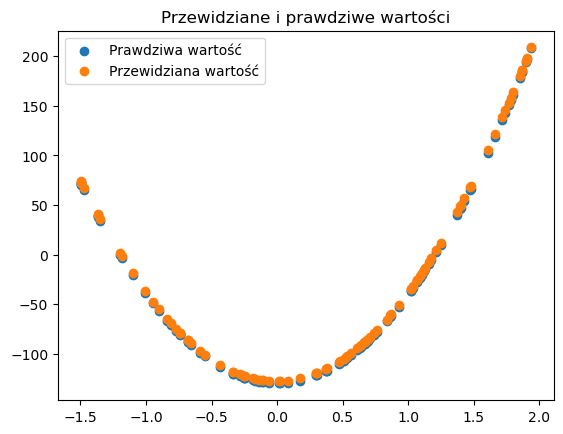

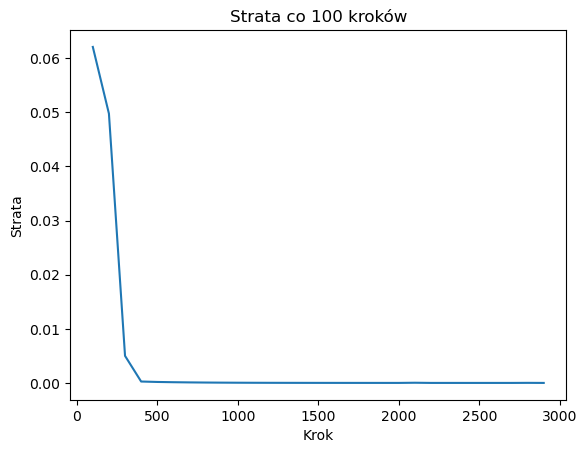

Krok 100, strata: 0.06799708306789398
Krok 200, strata: 0.06330572813749313
Krok 300, strata: 0.0594157837331295
Krok 400, strata: 0.05072895437479019
Krok 500, strata: 0.03543689846992493
Krok 600, strata: 0.01289184670895338
Krok 700, strata: 0.002295840997248888
Krok 800, strata: 0.0014386948896571994
Krok 900, strata: 0.0011076444061473012
Krok 1000, strata: 0.0008592554368078709
Krok 1100, strata: 0.0006555230938829482
Krok 1200, strata: 0.0004855977022089064
Krok 1300, strata: 0.00034617690835148096
Krok 1400, strata: 0.00023629538191016763
Krok 1500, strata: 0.0001551296591060236
Krok 1600, strata: 0.00010005293734138831
Krok 1700, strata: 6.57006457913667e-05
Krok 1800, strata: 4.542351598502137e-05
Krok 1900, strata: 3.3575637644389644e-05
Krok 2000, strata: 2.6460440494702198e-05
Krok 2100, strata: 2.199042501160875e-05
Krok 2200, strata: 1.904256350826472e-05
Krok 2300, strata: 1.7003529137582518e-05
Krok 2400, strata: 1.5524878108408302e-05
Krok 2500, strata: 1.440368487237

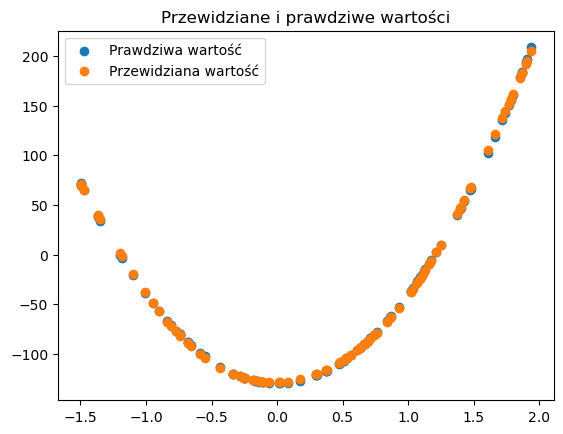

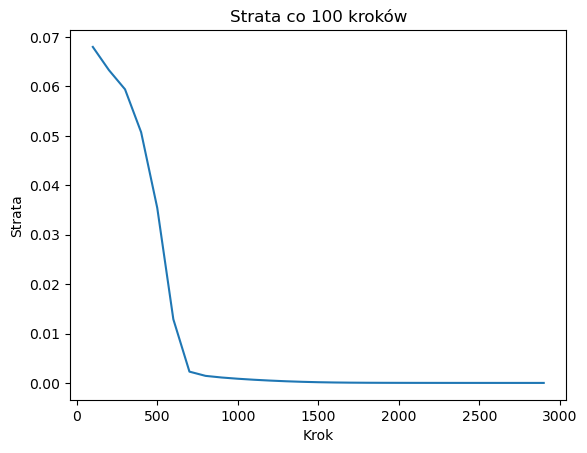

Krok 100, strata: 0.0753660574555397
Krok 200, strata: 0.06006214767694473
Krok 300, strata: 0.03912752866744995
Krok 400, strata: 0.023293612524867058
Krok 500, strata: 0.010661071166396141
Krok 600, strata: 0.0007598492666147649
Krok 700, strata: 0.00010529470455367118
Krok 800, strata: 5.091605271445587e-05
Krok 900, strata: 4.300934597267769e-05
Krok 1000, strata: 4.0072103729471564e-05
Krok 1100, strata: 3.790926348301582e-05
Krok 1200, strata: 3.5998767998535186e-05
Krok 1300, strata: 3.4223379770992324e-05
Krok 1400, strata: 3.2529631425859407e-05
Krok 1500, strata: 3.08868802676443e-05
Krok 1600, strata: 2.9281089155119844e-05
Krok 1700, strata: 2.770757782855071e-05
Krok 1800, strata: 2.616775054775644e-05
Krok 1900, strata: 2.4665685486979783e-05
Krok 2000, strata: 2.3206373953144066e-05
Krok 2100, strata: 2.1795076463604346e-05
Krok 2200, strata: 2.0435720216482878e-05
Krok 2300, strata: 1.9131308363284916e-05
Krok 2400, strata: 1.7883618056657724e-05
Krok 2500, strata: 1.66

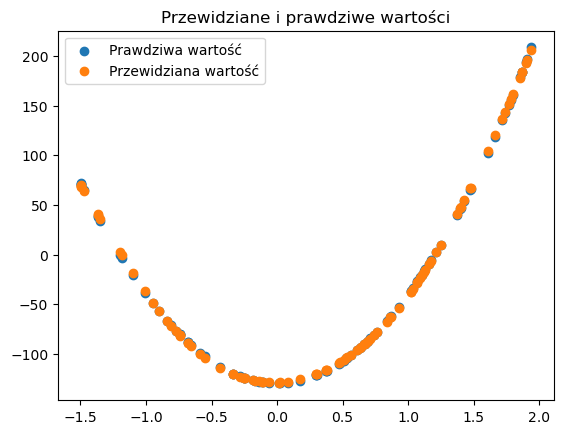

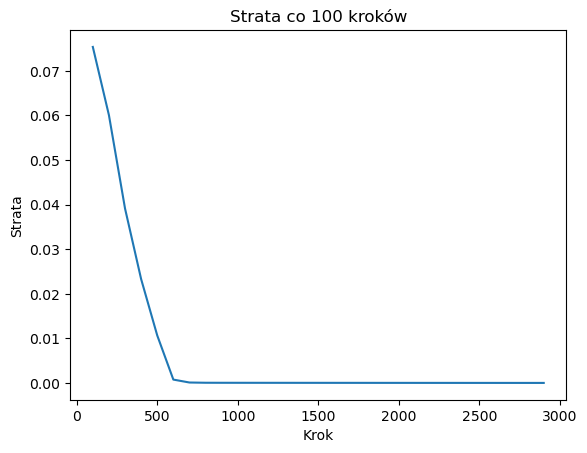

In [11]:
# trening wszystkich modeli
model_1_5_1, lista_modeli_1_5_1, x_train_min, x_train_max, y_train_min, y_train_max = trening(model_1_5_1, x_list_square_simple, y_list_square_simple, 3000)
model_1_10_1, lista_modeli_1_10_1, *_ = trening(model_1_10_1, x_list_square_simple, y_list_square_simple, 3000)
model_1_5_5_1, lista_modeli_1_5_5_1, *_ = trening(model_1_5_5_1, x_list_square_simple, y_list_square_simple, 3000)

In [12]:
def testuj(model, test_x_list, test_y_list, czy_znormalizowac, x_min=None, x_max=None, y_min=None, y_max=None):
    criterion = nn.MSELoss()
    model.eval()

    with torch.no_grad():

        x = torch.tensor(test_x_list, dtype=torch.float32).reshape(-1, 1).to(device)
        y = torch.tensor(test_y_list, dtype=torch.float32).reshape(-1, 1).to(device)

        if czy_znormalizowac:
            x_normalized = (x - x_min) / (x_max - x_min)
            y_normalized = (y - y_min) / (y_max - y_min)
        else:
            x_normalized = x
            y_normalized = y

        y_pred = model(x_normalized)

        loss = criterion(y_pred, y_normalized)

        if czy_znormalizowac:
            print(f"Strata (znormalizowana): {loss.item()}")

            y_pred_denorm = y_pred * (y_max - y_min) + y_min
            real_loss = criterion(y_pred_denorm, y)

            print(f"Strata (nieznormalizowana): {real_loss.item()}")
        else:
            print(f"Strata: {loss.item()}")

        x_plot = x.cpu().numpy()
        y_plot = y.cpu().numpy()

        if czy_znormalizowac:
            y_pred_plot = y_pred_denorm.cpu().numpy()
        else:
            y_pred_plot = y_pred.cpu().numpy()

        plt.scatter(x_plot, y_plot)
        plt.scatter(x_plot, y_pred_plot)
        plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
        plt.show()

    return loss.item()

=== Model 1-5-1 ===
Strata (znormalizowana): 3.878753341268748e-05
Strata (nieznormalizowana): 4.448670864105225


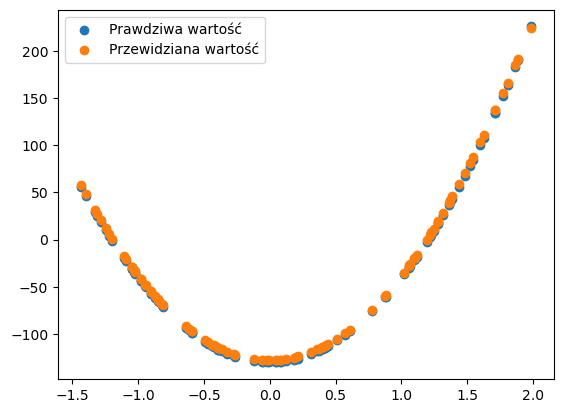

=== Model 1-10-1 ===
Strata (znormalizowana): 1.4222334357327782e-05
Strata (nieznormalizowana): 1.6312053203582764


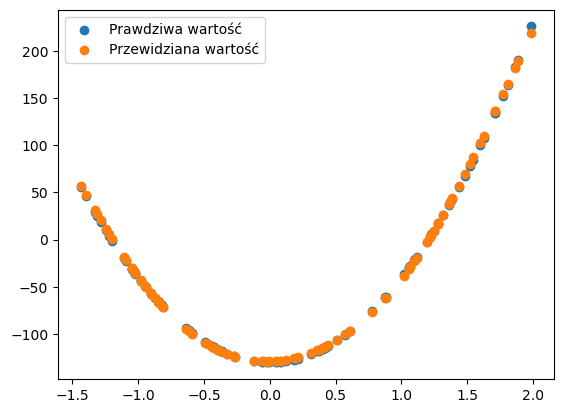

=== Model 1-5-5-1 ===
Strata (znormalizowana): 1.5071968846314121e-05
Strata (nieznormalizowana): 1.7286553382873535


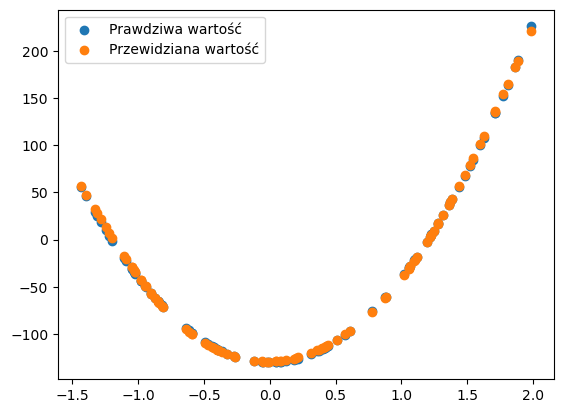

1.5071968846314121e-05

In [13]:

print("=== Model 1-5-1 ===")
testuj(
    model_1_5_1,
    test_x_list_square_simple,
    test_y_list_square_simple,
    czy_znormalizowac, 
    x_train_min, x_train_max, y_train_min, y_train_max
)

print("=== Model 1-10-1 ===")
testuj(
    model_1_10_1,
    test_x_list_square_simple,
    test_y_list_square_simple,
    czy_znormalizowac,
    x_train_min, x_train_max, y_train_min, y_train_max
)

print("=== Model 1-5-5-1 ===")
testuj(
    model_1_5_5_1,
    test_x_list_square_simple,
    test_y_list_square_simple,
    czy_znormalizowac,
    x_train_min, x_train_max, y_train_min, y_train_max
)

In [14]:
# Funkcja do wyciągania wag z warstw liniowych

def get_weights_and_bias(linear_layer):
    print(f"Waga: {linear_layer.weight.data.cpu().numpy()}")
    print(f"Bias: {linear_layer.bias.data}")

# Przykład wyciągniecia wag z pierwszej warstwy liniowej
layer = model_1_5_1[0]
get_weights_and_bias(layer)

Waga: [[ 2.4134161 ]
 [-4.79037   ]
 [-4.1942987 ]
 [ 0.24784704]
 [-2.9979775 ]]
Bias: tensor([-1.6669,  5.1209, -0.7083,  0.5490, -0.7945])


In [36]:
# Wyciągnij wagi ze wszystkich warstw liniowych i wklej je do swojego modelu w numpy.
# Uważaj na orientację wagi, być może trzeba będzie ją transponować!!! Pytorch może inaczej wymnażać X i weights niż wasz kod.

# Tu zrób kod

def pytorch_to_mlp(model, act_func, x_train_min, x_train_max, y_train_min, y_train_max):
    w = []
    biases_w = []
    layer_num = []

    for layer in model:
        if isinstance(layer, nn.Linear):
            weight = layer.weight.detach().cpu().numpy().T.astype(np.float32)
            bias = layer.bias.detach().cpu().numpy().astype(np.float32)

            w.append(weight)
            biases_w.append(bias)

            if len(layer_num) == 0:
                layer_num.append(layer.in_features)
            layer_num.append(layer.out_features)
    print(w)
    print(biases_w)
    return MLP(layer_num, act_func, w, biases_w, x_train_min, x_train_max, y_train_min, y_train_max)

[array([[ 2.4134161 , -4.79037   , -4.1942987 ,  0.24784704, -2.9979775 ]],
      dtype=float32), array([[ 1.0406044],
       [-2.4895554],
       [ 2.142425 ],
       [ 0.809591 ],
       [ 1.8082001]], dtype=float32)]
[array([-1.6668663 ,  5.1208706 , -0.7082681 ,  0.54904896, -0.79446256],
      dtype=float32), array([1.1293604], dtype=float32)]
[array([[-6.6586223 , -1.3115373 ,  0.11834943,  0.39464954, -0.39996725,
         0.39789417,  3.481444  , -2.9891067 , -0.20237374, -6.6501207 ]],
      dtype=float32), array([[-1.6276826 ],
       [ 0.79148704],
       [ 0.1957359 ],
       [ 0.13540539],
       [ 0.32838523],
       [ 0.05669196],
       [ 0.9147815 ],
       [ 0.7465915 ],
       [ 0.21716483],
       [ 1.1638461 ]], dtype=float32)]
[array([ 6.502833  , -0.288148  , -0.413822  , -0.9016209 ,  0.16102009,
       -0.70205253, -2.3513806 , -0.45871374,  0.6833345 ,  0.06864503],
      dtype=float32), array([0.45232284], dtype=float32)]
[array([[-3.928199 , -3.2330294,  4.8

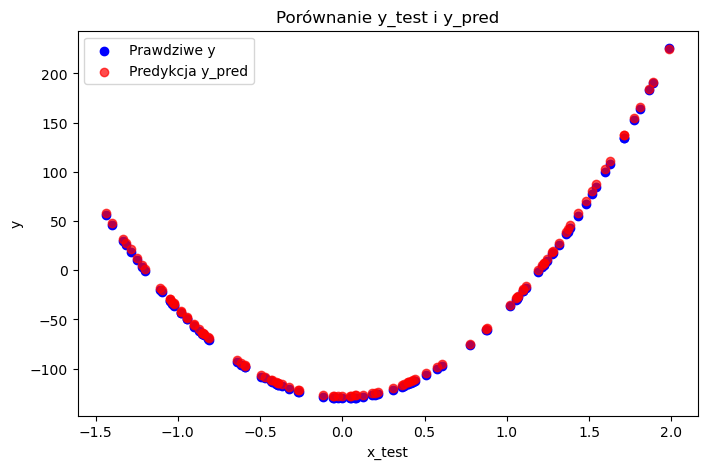

MSE dla modelu 1_5_1: 4.448654
============ 1-10-1 ==========


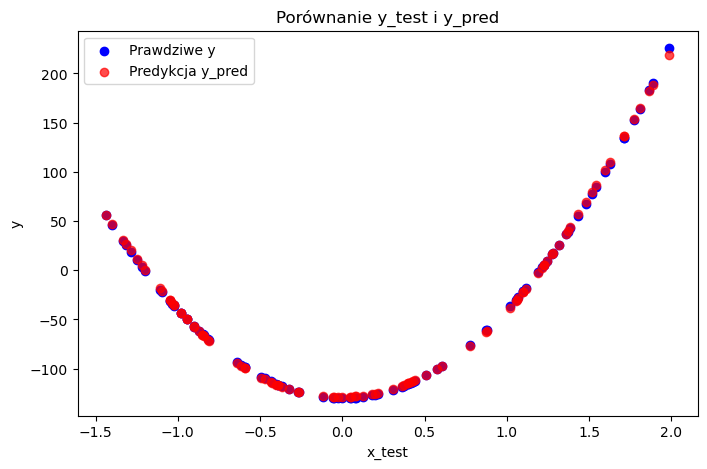

MSE dla modelu 1_10_1: 1.631187
============ 1-5-5-1 ==========


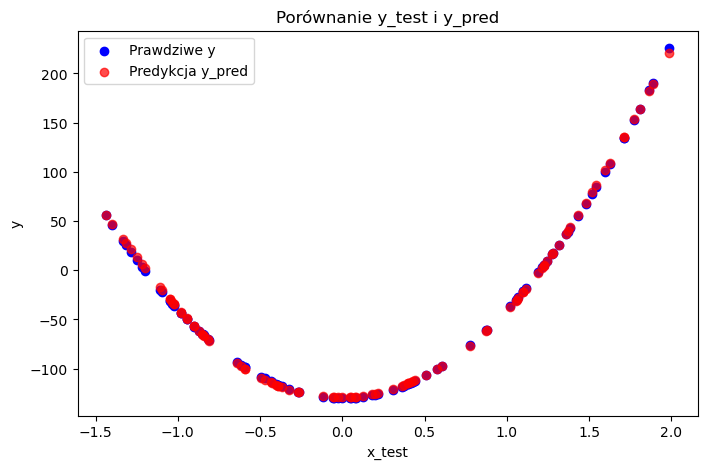

MSE dla modelu 1_5_1: 1.728641


In [63]:
mlp_1_5_1 = pytorch_to_mlp(model_1_5_1, sigmoid, x_train_min, x_train_max, y_train_min, y_train_max)
mlp_1_10_1 = pytorch_to_mlp(model_1_10_1, sigmoid, x_train_min, x_train_max, y_train_min, y_train_max)
mlp_1_5_5_1 = pytorch_to_mlp(model_1_5_5_1, sigmoid, x_train_min, x_train_max, y_train_min, y_train_max)

x_test_np = np.array(test_x_list_square_simple).reshape(-1, 1)
y_test_np = np.array(test_y_list_square_simple).reshape(-1, 1)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)


print('============ 1-5-1 ==========')
y_pred = mlp_1_5_1.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred)
print(f"MSE dla modelu 1_5_1: {loss:.6f}")
print('============ 1-10-1 ==========')
y_pred_2 = mlp_1_10_1.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred_2, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred_2)
print(f"MSE dla modelu 1_10_1: {loss:.6f}")
print('============ 1-5-5-1 ==========')
y_pred_3 = mlp_1_5_5_1.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred_3, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred_3)
print(f"MSE dla modelu 1_5_1: {loss:.6f}")

### Najlepszy model na square simple

In [ ]:
# zapisane wartości wag
'''
# model 1-5-1
# wagi
[array([[ 2.4134161 , -4.79037   , -4.1942987 ,  0.24784704, -2.9979775 ]],
      dtype=float32), array([[ 1.0406044],
       [-2.4895554],
       [ 2.142425 ],
       [ 0.809591 ],
       [ 1.8082001]], dtype=float32)]
# biasy
[array([-1.6668663 ,  5.1208706 , -0.7082681 ,  0.54904896, -0.79446256],
      dtype=float32), array([1.1293604], dtype=float32)]
# model 1-10-1
# wagi
[array([[-6.6586223 , -1.3115373 ,  0.11834943,  0.39464954, -0.39996725,
         0.39789417,  3.481444  , -2.9891067 , -0.20237374, -6.6501207 ]],
      dtype=float32), array([[-1.6276826 ],
       [ 0.79148704],
       [ 0.1957359 ],
       [ 0.13540539],
       [ 0.32838523],
       [ 0.05669196],
       [ 0.9147815 ],
       [ 0.7465915 ],
       [ 0.21716483],
       [ 1.1638461 ]], dtype=float32)]
# biasy
[array([ 6.502833  , -0.288148  , -0.413822  , -0.9016209 ,  0.16102009,
       -0.70205253, -2.3513806 , -0.45871374,  0.6833345 ,  0.06864503],
      dtype=float32), array([0.45232284], dtype=float32)]
# model 1-5-5-1
# wagi
[array([[-3.928199 , -3.2330294,  4.8786674, -4.94121  , -5.1407466]],
      dtype=float32), array([[-1.4370382 , -0.10253819,  0.8248019 , -1.5640156 , -0.909479  ],
       [-1.3780788 ,  2.4548273 ,  1.3375878 , -0.87545276, -0.7627141 ],
       [ 2.3753862 , -3.8714433 , -0.67315096,  1.7772838 , -0.40719455],
       [-2.9129322 ,  1.8265563 ,  1.9921486 , -2.8224492 , -0.84162503],
       [-2.7674294 , -0.00642173,  1.4495955 , -2.3370354 , -0.72141635]],
      dtype=float32), array([[ 1.3071079 ],
       [ 1.3270745 ],
       [-0.6303421 ],
       [ 0.4680601 ],
       [ 0.24457042]], dtype=float32)]
# biasy
[array([3.904961  , 0.7336497 , 0.24509774, 2.3577764 , 5.612671  ],
      dtype=float32), array([ 0.58432025, -0.7154491 , -0.15142117,  0.46507317, -0.21430185],
      dtype=float32), array([0.42637455], dtype=float32)]
'''

In [11]:
# wybrany model: 1-10-1: po 3000 kroków

x_min_ss, x_max_ss, y_min_ss, y_max_ss = min_max_vals(x_list_square_simple, y_list_square_simple)

layer_num = [1, 10, 1]

w = [
    np.array([[-6.6586223 , -1.3115373 ,  0.11834943,  0.39464954, -0.39996725,
                0.39789417,  3.481444  , -2.9891067 , -0.20237374, -6.6501207 ]],
              dtype=np.float32),
    np.array([[-1.6276826 ],
              [ 0.79148704],
              [ 0.1957359 ],
              [ 0.13540539],
              [ 0.32838523],
              [ 0.05669196],
              [ 0.9147815 ],
              [ 0.7465915 ],
              [ 0.21716483],
              [ 1.1638461 ]],
              dtype=np.float32)
]

biases_w = [
    np.array([ 6.502833  , -0.288148  , -0.413822  , -0.9016209 ,  0.16102009,
              -0.70205253, -2.3513806 , -0.45871374,  0.6833345 ,  0.06864503],
              dtype=np.float32),

    np.array([0.45232284], dtype=np.float32)
]

mlp = MLP(
    layer_num=layer_num,
    act_func=sigmoid,
    w=w,
    biases_w=biases_w,
    x_min=x_min_ss,
    x_max=x_max_ss,
    y_min=y_min_ss,
    y_max=y_max_ss
)

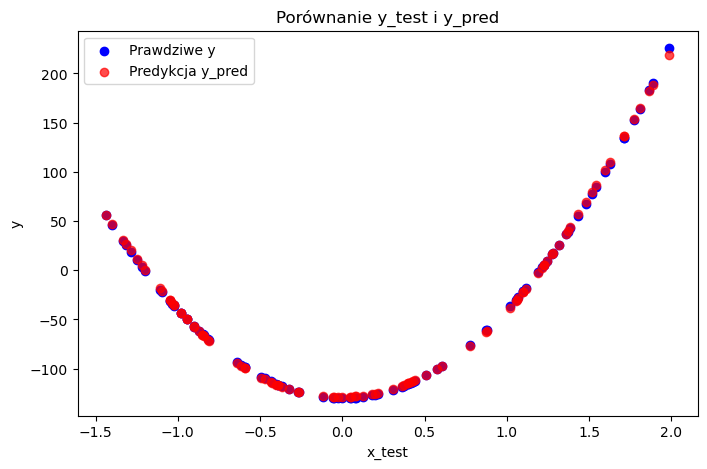

MSE dla modelu 1_10_1: 1.631191


In [10]:
# sprawdzenie:
x_test_np = np.array(test_x_list_square_simple).reshape(-1, 1)
y_test_np = np.array(test_y_list_square_simple).reshape(-1, 1)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

y_pred = mlp.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred)
print(f"MSE dla modelu 1_10_1: {loss:.6f}")

In [ ]:
# square simple jest prostym zbiorem, więc łatwo o mse < 9

### Trenowanie na steps large

In [13]:
# teraz steps large

x_list_steps_large = []
y_list_steps_large = []
for i, row in enumerate(data_steps_large):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    x_list_steps_large.append(x)
    y_list_steps_large.append(y)

# Przygotuj dane testujace
test_x_list_steps_large = []
test_y_list_steps_large = []
for i, row in enumerate(test_data_steps_large):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    test_x_list_steps_large.append(x)
    test_y_list_steps_large.append(y)


In [58]:

# modele bazowe te same

czy_znormalizowac = True
model_1_5_1_sl = copy.deepcopy(model_1_5_1_nietr)
model_1_10_1_sl = copy.deepcopy(model_1_10_1_nietr)
model_1_5_5_1_sl = copy.deepcopy(model_1_5_5_1_nietr)


Krok 100, strata: 0.06372851133346558
Krok 200, strata: 0.019149215891957283
Krok 300, strata: 0.009495855309069157
Krok 400, strata: 0.009257635101675987
Krok 500, strata: 0.009104747325181961
Krok 600, strata: 0.008974115364253521
Krok 700, strata: 0.008860842324793339
Krok 800, strata: 0.00876143854111433
Krok 900, strata: 0.00867411307990551
Krok 1000, strata: 0.008598105050623417
Krok 1100, strata: 0.00853312760591507
Krok 1200, strata: 0.008478989824652672
Krok 1300, strata: 0.00843533594161272
Krok 1400, strata: 0.008401477709412575
Krok 1500, strata: 0.008376330137252808
Krok 1600, strata: 0.008358488790690899
Krok 1700, strata: 0.008346389047801495
Krok 1800, strata: 0.00833850260823965
Krok 1900, strata: 0.008333501406013966
Krok 2000, strata: 0.008330345153808594
Krok 2100, strata: 0.008328292518854141
Krok 2200, strata: 0.008326854556798935
Krok 2300, strata: 0.008325737901031971
Krok 2400, strata: 0.00832477305084467
Krok 2500, strata: 0.00832387525588274
Krok 2600, strata

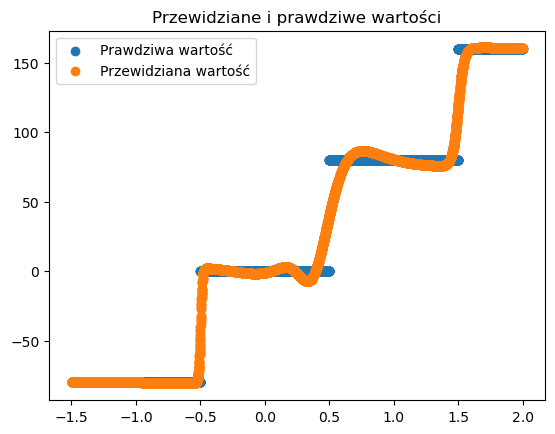

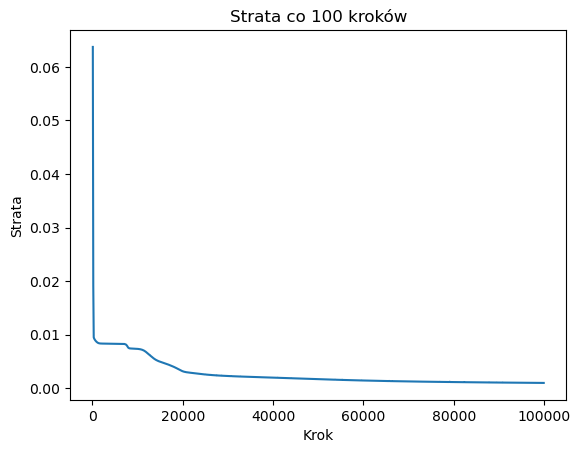

Krok 100, strata: 0.009260127320885658
Krok 200, strata: 0.008981267921626568
Krok 300, strata: 0.008798499591648579
Krok 400, strata: 0.008662545122206211
Krok 500, strata: 0.008563870564103127
Krok 600, strata: 0.008491952903568745
Krok 700, strata: 0.008439415134489536
Krok 800, strata: 0.008401412516832352
Krok 900, strata: 0.00837464164942503
Krok 1000, strata: 0.008357462473213673
Krok 1100, strata: 0.008357368409633636
Krok 1200, strata: 0.008338316343724728
Krok 1300, strata: 0.008333389647305012
Krok 1400, strata: 0.008330286480486393
Krok 1500, strata: 0.008328134194016457
Krok 1600, strata: 0.00833327230066061
Krok 1700, strata: 0.008325549773871899
Krok 1800, strata: 0.008324633352458477
Krok 1900, strata: 0.00832384079694748
Krok 2000, strata: 0.008323010057210922
Krok 2100, strata: 0.008322205394506454
Krok 2200, strata: 0.008321425877511501
Krok 2300, strata: 0.008320548571646214
Krok 2400, strata: 0.008319650776684284
Krok 2500, strata: 0.008318709209561348
Krok 2600, s

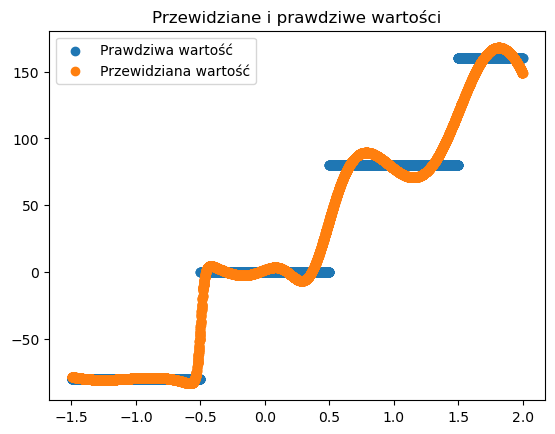

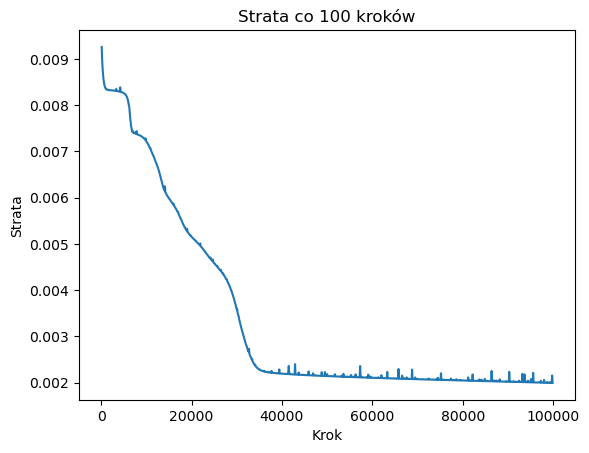

Krok 100, strata: 0.10211426019668579
Krok 200, strata: 0.03392845019698143
Krok 300, strata: 0.009074226021766663
Krok 400, strata: 0.008575564250349998
Krok 500, strata: 0.008431872352957726
Krok 600, strata: 0.008386597037315369
Krok 700, strata: 0.008371022529900074
Krok 800, strata: 0.008364190347492695
Krok 900, strata: 0.008359700441360474
Krok 1000, strata: 0.008355745114386082
Krok 1100, strata: 0.008351892232894897
Krok 1200, strata: 0.008348070085048676
Krok 1300, strata: 0.008344298228621483
Krok 1400, strata: 0.008340605534613132
Krok 1500, strata: 0.008337019011378288
Krok 1600, strata: 0.008333555422723293
Krok 1700, strata: 0.00833023153245449
Krok 1800, strata: 0.008327051997184753
Krok 1900, strata: 0.008324017748236656
Krok 2000, strata: 0.008321123197674751
Krok 2100, strata: 0.008318359963595867
Krok 2200, strata: 0.008315710350871086
Krok 2300, strata: 0.00831315666437149
Krok 2400, strata: 0.008310672827064991
Krok 2500, strata: 0.008308231830596924
Krok 2600, st

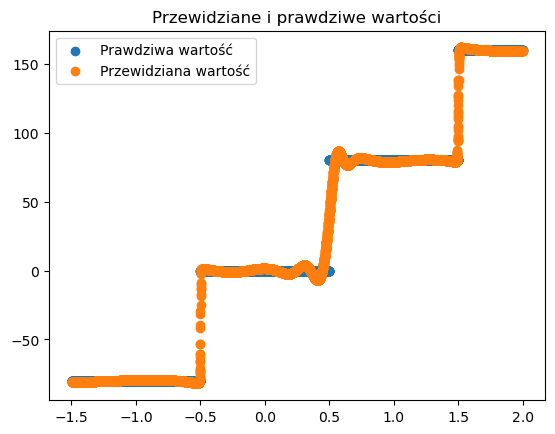

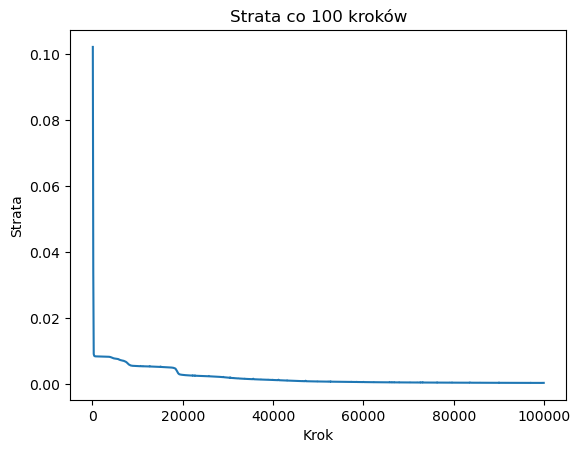

In [59]:
# trening wszystkich modeli
model_1_5_1_sl, lista_modeli_1_5_1_sl, x_train_min_sl, x_train_max_sl, y_train_min_sl, y_train_max_sl = trening(model_1_5_1_sl, x_list_steps_large, y_list_steps_large, 100000)
model_1_10_1_sl, lista_modeli_1_10_1_sl, *_ = trening(model_1_10_1_sl, x_list_steps_large, y_list_steps_large, 100000)
model_1_5_5_1_sl, lista_modeli_1_5_5_1_sl, *_ = trening(model_1_5_5_1_sl, x_list_steps_large, y_list_steps_large, 100000)

=== Model 1-5-1 ===
Strata (znormalizowana): 0.0008981492137536407
Strata (nieznormalizowana): 51.733394622802734


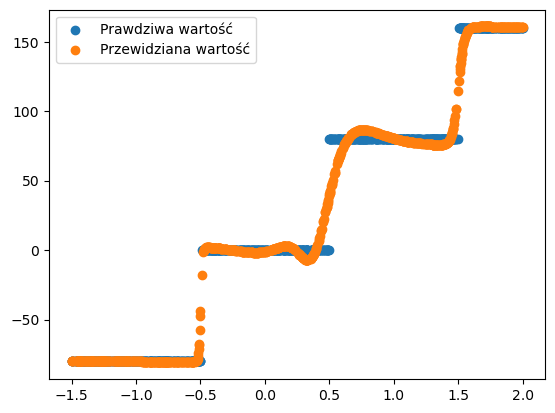

=== Model 1-10-1 ===
Strata (znormalizowana): 0.0019779291469603777
Strata (nieznormalizowana): 113.92871856689453


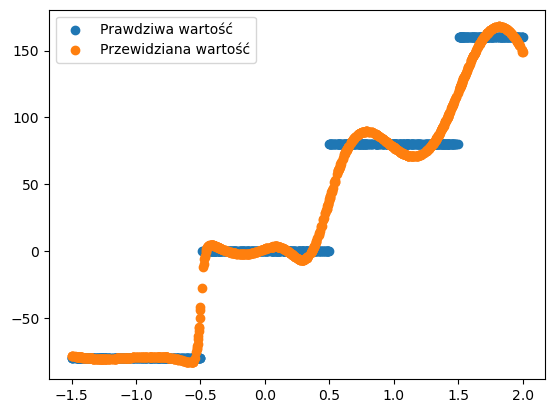

=== Model 1-5-5-1 ===
Strata (znormalizowana): 0.0003306367143522948
Strata (nieznormalizowana): 19.0446720123291


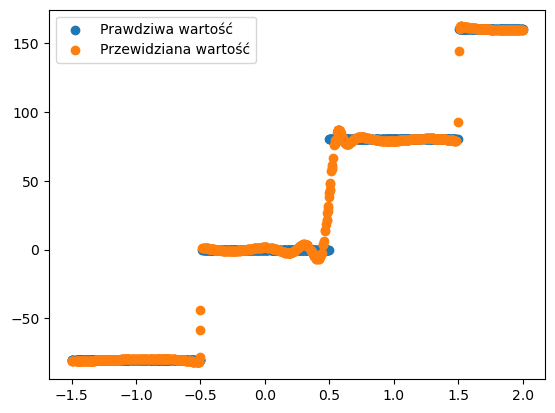

0.0003306367143522948

In [60]:
print("=== Model 1-5-1 ===")
testuj(
    model_1_5_1_sl,
    test_x_list_steps_large,
    test_y_list_steps_large,
    czy_znormalizowac, 
    x_train_min_sl, x_train_max_sl, y_train_min_sl, y_train_max_sl
)

print("=== Model 1-10-1 ===")
testuj(
    model_1_10_1_sl,
    test_x_list_steps_large,
    test_y_list_steps_large,
    czy_znormalizowac, 
    x_train_min_sl, x_train_max_sl, y_train_min_sl, y_train_max_sl
)
print("=== Model 1-5-5-1 ===")
testuj(
    model_1_5_5_1_sl,
    test_x_list_steps_large,
    test_y_list_steps_large,
    czy_znormalizowac, 
    x_train_min_sl, x_train_max_sl, y_train_min_sl, y_train_max_sl
)

In [64]:
# konwersja
mlp_1_5_1_sl = pytorch_to_mlp(model_1_5_1_sl, sigmoid, x_train_min_sl, x_train_max_sl, y_train_min_sl, y_train_max_sl)
mlp_1_10_1_sl = pytorch_to_mlp(model_1_10_1_sl, sigmoid, x_train_min_sl, x_train_max_sl, y_train_min_sl, y_train_max_sl)
mlp_1_5_5_1_sl = pytorch_to_mlp(model_1_5_5_1_sl, sigmoid, x_train_min_sl, x_train_max_sl, y_train_min_sl, y_train_max_sl)

x_test_np = np.array(test_x_list_steps_large).reshape(-1, 1)
y_test_np = np.array(test_y_list_steps_large).reshape(-1, 1)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)




[array([[ 29.950073, -41.796356,  23.215424, 157.34729 , 477.79068 ]],
      dtype=float32), array([[ 5.2798553 ],
       [ 2.259125  ],
       [-2.7233157 ],
       [ 0.35803148],
       [ 0.34839764]], dtype=float32)]
[array([ -15.919666,   21.70603 ,  -12.479912, -134.8672  , -136.56609 ],
      dtype=float32), array([-2.2593749], dtype=float32)]
[array([[-2.8207226e+00, -1.5932848e+01,  9.4887886e+00,  8.2728686e-03,
        -3.2217453e+00, -3.2427273e+01, -2.9515328e+00, -2.2154921e+02,
         4.0819907e+00, -2.1093437e+01]], dtype=float32), array([[ 3.0616121],
       [-2.3388202],
       [ 0.8560835],
       [-1.5580223],
       [ 0.5219865],
       [ 1.7410147],
       [ 3.0815828],
       [-0.3998466],
       [-2.208872 ],
       [-3.3068671]], dtype=float32)]
[array([ 2.3632152 , 13.783883  , -1.584651  ,  5.7352285 ,  0.82487035,
       16.271587  ,  3.290071  , 63.357365  , -4.7703514 , 10.990101  ],
      dtype=float32), array([-0.39542618], dtype=float32)]
[array([[16.5

============ 1-5-1 ==========


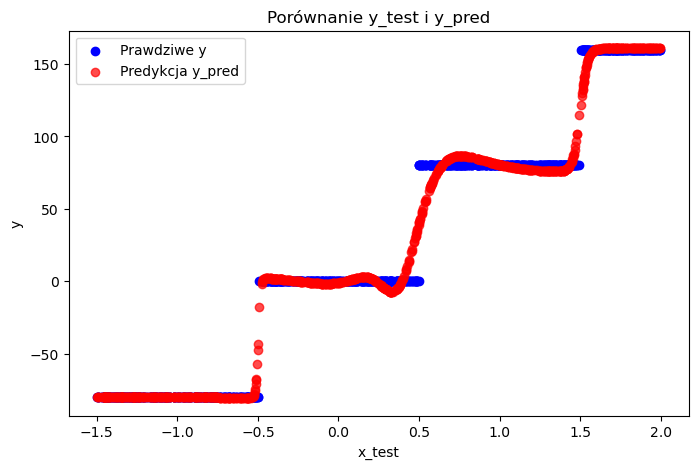

MSE dla modelu 1_5_1: 51.733335
============ 1-10-1 ==========


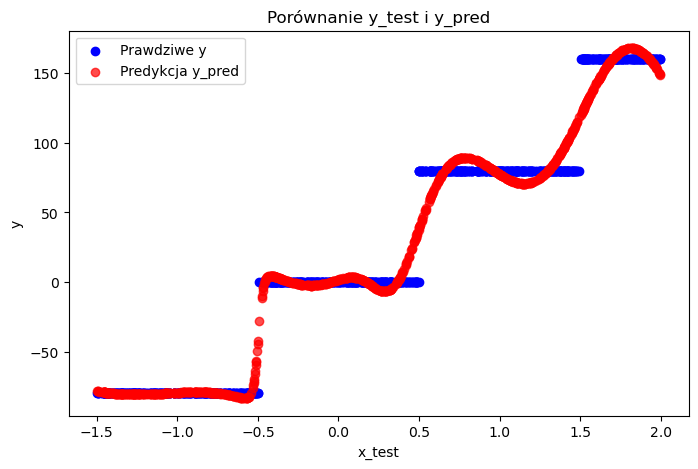

MSE dla modelu 1_10_1: 113.928746
============ 1-5-5-1 ==========


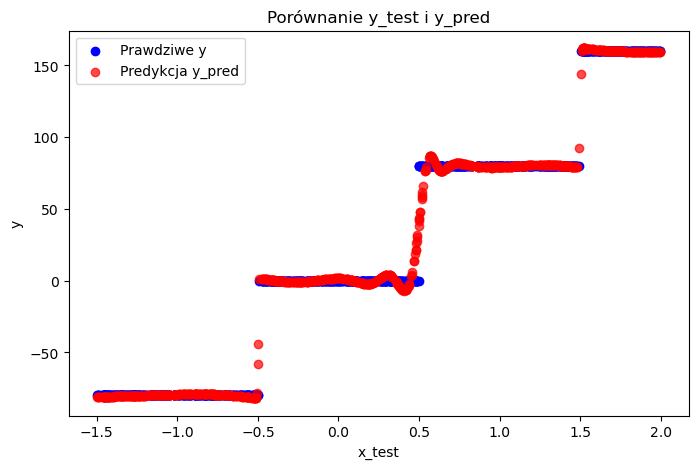

MSE dla modelu 1_5_1: 19.044666


In [65]:
print('============ 1-5-1 ==========') # test poprawności modeli po konwersji
y_pred = mlp_1_5_1_sl.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred)
print(f"MSE dla modelu 1_5_1: {loss:.6f}")
print('============ 1-10-1 ==========')
y_pred_2 = mlp_1_10_1_sl.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred_2, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred_2)
print(f"MSE dla modelu 1_10_1: {loss:.6f}")
print('============ 1-5-5-1 ==========')
y_pred_3 = mlp_1_5_5_1_sl.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred_3, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred_3)
print(f"MSE dla modelu 1_5_1: {loss:.6f}")

In [ ]:
# jak widać przybliżenia dalej są bliskie prawdziwym y, czyli konwersja działa poprawnie

In [ ]:
# zapisane wartości wag:
'''
# model 1-5-1
# wagi
[array([[ 29.950073, -41.796356,  23.215424, 157.34729 , 477.79068 ]],
      dtype=float32), array([[ 5.2798553 ],
       [ 2.259125  ],
       [-2.7233157 ],
       [ 0.35803148],
       [ 0.34839764]], dtype=float32)]
# biasy
[array([ -15.919666,   21.70603 ,  -12.479912, -134.8672  , -136.56609 ],
      dtype=float32), array([-2.2593749], dtype=float32)]

# model 1-10-1
# wagi
[array([[-2.8207226e+00, -1.5932848e+01,  9.4887886e+00,  8.2728686e-03,
        -3.2217453e+00, -3.2427273e+01, -2.9515328e+00, -2.2154921e+02,
         4.0819907e+00, -2.1093437e+01]], dtype=float32), array([[ 3.0616121],
       [-2.3388202],
       [ 0.8560835],
       [-1.5580223],
       [ 0.5219865],
       [ 1.7410147],
       [ 3.0815828],
       [-0.3998466],
       [-2.208872 ],
       [-3.3068671]], dtype=float32)]
# biasy
[array([ 2.3632152 , 13.783883  , -1.584651  ,  5.7352285 ,  0.82487035,
       16.271587  ,  3.290071  , 63.357365  , -4.7703514 , 10.990101  ],
      dtype=float32), array([-0.39542618], dtype=float32)]

# model 1-5-5-1
# wagi
[array([[16.514313, 12.66824 , 30.987484, 19.587328, 30.164509]],
      dtype=float32), array([[ 3.59899384e+02,  4.39351511e+00, -1.37487018e+00,
        -1.24766588e+00, -2.74116955e+01],
       [ 4.39952301e+02, -5.36281586e+00,  2.02177072e+00,
        -1.68774664e+00, -2.03623962e+01],
       [ 2.21064255e+02,  2.46930580e+01, -2.67108887e-01,
        -1.60044155e+01,  1.40691395e+01],
       [ 4.21406250e+02, -1.14528885e+01, -8.00049603e-01,
         8.93452644e+00, -3.13034439e+01],
       [ 7.26228561e+01,  4.17294807e+01, -8.07945877e-02,
        -2.83868074e+00,  1.76456207e+02]], dtype=float32), array([[ 0.35001677],
       [-1.6252344 ],
       [ 2.0832067 ],
       [-7.069192  ],
       [ 0.34875926]], dtype=float32)]
# biasy
[array([ -5.196937 ,  -6.1209373, -19.456848 , -10.681319 , -25.665949 ],
      dtype=float32), array([-173.20412   ,    2.6055617 ,    0.25056368,   -2.2415955 ,
        -31.928637  ], dtype=float32), array([1.0134785], dtype=float32)]
'''

In [17]:
# najlepszy model: 1-5-5-1: po 100000 krokach

x_min_sl, x_max_sl, y_min_sl, y_max_sl = min_max_vals(x_list_steps_large, y_list_steps_large)

layer_num_sl = [1, 5, 5, 1]

w_sl = [
    np.array([[16.514313, 12.66824 , 30.987484, 19.587328, 30.164509]],
             dtype=np.float32),

    np.array([[ 3.59899384e+02,  4.39351511e+00, -1.37487018e+00,
                -1.24766588e+00, -2.74116955e+01],
              [ 4.39952301e+02, -5.36281586e+00,  2.02177072e+00,
                -1.68774664e+00, -2.03623962e+01],
              [ 2.21064255e+02,  2.46930580e+01, -2.67108887e-01,
                -1.60044155e+01,  1.40691395e+01],
              [ 4.21406250e+02, -1.14528885e+01, -8.00049603e-01,
                8.93452644e+00, -3.13034439e+01],
              [ 7.26228561e+01,  4.17294807e+01, -8.07945877e-02,
                -2.83868074e+00,  1.76456207e+02]],
             dtype=np.float32),

    np.array([[ 0.35001677],
              [-1.6252344 ],
              [ 2.0832067 ],
              [-7.069192  ],
              [ 0.34875926]],
             dtype=np.float32)
]

biases_w_sl = [
    np.array([ -5.196937 ,  -6.1209373, -19.456848 , -10.681319 , -25.665949 ],
             dtype=np.float32),

    np.array([-173.20412   ,    2.6055617 ,    0.25056368,
               -2.2415955 ,  -31.928637  ],
             dtype=np.float32),

    np.array([1.0134785], dtype=np.float32)
]

mlp_sl = MLP(
    layer_num=layer_num_sl,
    act_func=sigmoid,
    w=w_sl,
    biases_w=biases_w_sl,
    x_min=x_min_sl,
    x_max=x_max_sl,
    y_min=y_min_sl,
    y_max=y_max_sl
)

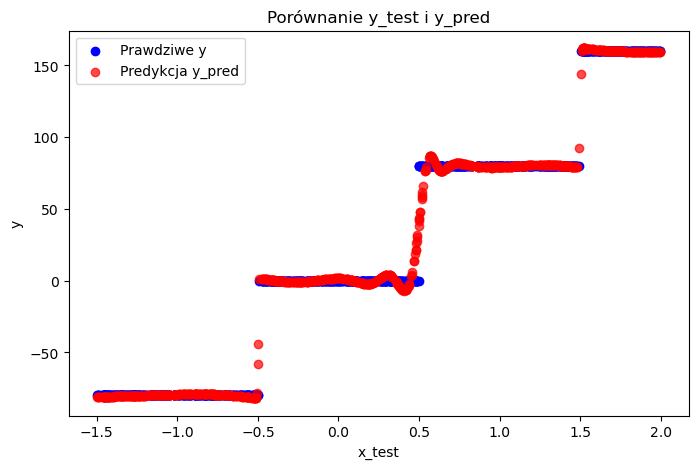

MSE dla modelu 1_5_1: 19.044639


In [18]:
x_test_np = np.array(test_x_list_steps_large).reshape(-1, 1)
y_test_np = np.array(test_y_list_steps_large).reshape(-1, 1)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)


y_pred_sl = mlp_sl.calc(x_test_np)
plt.figure(figsize=(8,5))
plt.scatter(x_test_np, y_test_np, color='blue', label='Prawdziwe y')
plt.scatter(x_test_np, y_pred_sl, color='red', label='Predykcja y_pred', alpha=0.7)
plt.xlabel('x_test')
plt.ylabel('y')
plt.title('Porównanie y_test i y_pred')
plt.legend()
plt.show()
loss = mse(y_test_np, y_pred_sl)
print(f"MSE dla modelu 1_5_1: {loss:.6f}")